---
# Faza 3 — Naive Bayes

## 3a. Wybór wariantu i uzasadnienie metryk

### Który wariant Naive Bayesa?

Naive Bayes nie jest jednym modelem — każdy wariant zakłada coś innego o rozkładzie cech:

| Wariant | Założenie o cechach | Kiedy używać |
|---|---|---|
| **GaussianNB** | Ciągłe, rozkład normalny | Dane numeryczne |
| **BernoulliNB** | Binarne (0/1) | Bag-of-words, flagi |
| **MultinomialNB** | Liczby całkowite ≥ 0 (zliczenia) | NLP, zliczenia |
| **ComplementNB** | j.w. + lepsza obsługa nierównowagi | NLP z imbalanced data |

Nasze cechy (`est_diameter_min`, `relative_velocity`, `miss_distance`, `absolute_magnitude`) są ciągłe i numeryczne — `BernoulliNB` i `MultinomialNB` po prostu nie pasują. Jedynym sensownym wyborem jest **GaussianNB**.

### Dlaczego te metryki?

Zadanie ma bardzo konkretny kontekst decyzyjny:
- **FN = przeoczony obiekt zagrażający Ziemi** — jedna taka pomyłka to katastrofa. Koszt praktycznie nieskończony.
- **FP = fałszywy alarm** — angażujemy zasoby agencji kosmicznej do czegoś, co okazuje się bezpieczne. Kosztowne, ale przeżyjemy.

Z tego wynika kilka rzeczy:
- **Recall = 1.0** to twardy wymóg — żadnego FN nie akceptujemy
- **Precision** optymalizujemy w ramach tego ograniczenia — chcemy jak najmniej fałszywych alarmów
- **ROC-AUC** używamy do CV, bo jest niezależne od progu i stabilne przy nierównowadze
- **Krzywa PR** jest tutaj ważniejsza niż ROC — przy rozkładzie klas 1:9 krzywa ROC wygląda lepiej niż jest, bo TN mocno zaniża FPR. PR-AUC pokazuje, co naprawdę się dzieje z klasą mniejszościową
- **Accuracy i Balanced Accuracy** raportujemy pomocniczo do porównania z innymi modelami w zespole


In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    recall_score, precision_score, roc_auc_score,
    balanced_accuracy_score, classification_report,
    confusion_matrix, roc_curve, precision_recall_curve, auc
)
from sklearn.model_selection import StratifiedKFold, cross_val_predict
import numpy as np
import matplotlib.pyplot as plt

## 3b. Badanie hiperparametrów — `var_smoothing` i `priors`

GaussianNB ma dwa parametry, które warto poeksperymentować:

- **`var_smoothing`** — dodaje ułamek maksymalnej wariancji do wszystkich cech, zapobiegając dzieleniu przez zero. W praktyce działa jak miękka regularyzacja: małe wartości = model bardziej ufa danym, duże = wyrównuje wariancje i traci nieco czułości na różnice między cechami.

- **`priors`** — a priori prawdopodobieństwa klas. To ciekawy parametr przy nierównowadze:
  - `None` → estymowane z danych (~[0.90, 0.10]) — model "wie", że zdarzeń hazardous jest mało i jest w stosunku do nich zachowawczy
  - `[0.5, 0.5]` → równe szanse — podkręcamy szansę klasy mniejszościowej, co przekłada się na wyższy Recall bez konieczności bardzo agresywnego progu
  - odwrócone proporcje → maksymalne faworyzowanie klasy hazardous

Przetestujemy wszystkie trzy warianty priors, a `var_smoothing` przeszukamy po siatce logarytmicznej przez 5-fold CV z metryką ROC-AUC.


In [ ]:
var_smoothing_values = np.logspace(-11, 0, 13)  # 13 wartości od 1e-11 do 1e0
positive_rate = y_train.mean()
negative_rate = 1 - positive_rate

priors_options = {
    'naturalne': None,
    'rowne_0_5_0_5': [0.5, 0.5],
    'balanced_odwrocone': [positive_rate, negative_rate]
}
priors_display = {
    'naturalne': 'naturalne (z danych)',
    'rowne_0_5_0_5': 'rowne [0.5, 0.5]',
    'balanced_odwrocone': 'odwrocone / balanced'
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []

for priors_key, priors_val in priors_options.items():
    aucs = []
    for vs in var_smoothing_values:
        fold_scores = []
        for train_idx, val_idx in cv.split(X_train, y_train):
            Xtr, Xval = X_train.iloc[train_idx], X_train.iloc[val_idx]
            ytr, yval = y_train.iloc[train_idx], y_train.iloc[val_idx]
            pipeline = Pipeline([
                ('scaler', RobustScaler()),
                ('model', GaussianNB(var_smoothing=vs, priors=priors_val))
            ])
            pipeline.fit(Xtr, ytr)
            proba = pipeline.predict_proba(Xval)[:, 1]
            fold_scores.append(roc_auc_score(yval, proba))
        mean_auc = np.mean(fold_scores)
        std_auc = np.std(fold_scores)
        aucs.append(mean_auc)
        results.append({
            'priors': priors_key,
            'priors_opis': priors_display[priors_key],
            'var_smoothing': vs,
            'roc_auc_cv': mean_auc,
            'roc_auc_cv_std': std_auc
        })
    best_idx = np.argmax(aucs)
    print(
        f"Priors: {priors_display[priors_key]:24s} | najlepszy AUC: {max(aucs):.4f} "
        f"przy var_smoothing={var_smoothing_values[best_idx]:.2e}"
    )

results_df = pd.DataFrame(results)
results_df.sort_values('roc_auc_cv', ascending=False).head(10)


Priors: naturalne (z danych)     | najlepszy AUC: 0.8648 przy var_smoothing=1.00e-11
Priors: rowne [0.5, 0.5]         | najlepszy AUC: 0.8648 przy var_smoothing=1.00e-11
Priors: odwrocone / balanced     | najlepszy AUC: 0.8648 przy var_smoothing=1.00e-11


,priors,priors_opis,var_smoothing,roc_auc_cv,roc_auc_cv_std
0,naturalne,naturalne (z danych),1.000000e-11,0.864763,0.004764
1,naturalne,naturalne (z danych),8.254042e-11,0.864763,0.004764
2,naturalne,naturalne (z danych),6.812921e-10,0.864763,0.004764
26,balanced_odwrocone,odwrocone / balanced,1.000000e-11,0.864763,0.004764
15,rowne_0_5_0_5,"rowne [0.5, 0.5]",6.812921e-10,0.864763,0.004764
14,rowne_0_5_0_5,"rowne [0.5, 0.5]",8.254042e-11,0.864763,0.004764
13,rowne_0_5_0_5,"rowne [0.5, 0.5]",1.000000e-11,0.864763,0.004764
27,balanced_odwrocone,odwrocone / balanced,8.254042e-11,0.864763,0.004764
28,balanced_odwrocone,odwrocone / balanced,6.812921e-10,0.864763,0.004764
30,balanced_odwrocone,odwrocone / balanced,4.641589e-08,0.864763,0.004764


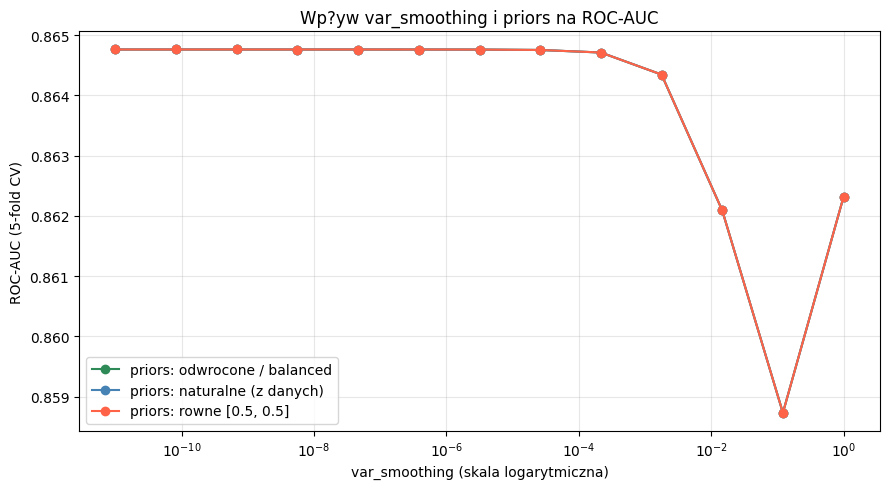

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = {'naturalne': 'steelblue', 'rowne_0_5_0_5': 'tomato', 'balanced_odwrocone': 'seagreen'}

for priors_key, group in results_df.groupby('priors'):
    ax.plot(group['var_smoothing'], group['roc_auc_cv'],
            marker='o', label=f"priors: {priors_display[priors_key]}",
            color=colors.get(priors_key, 'gray'))

ax.set_xscale('log')
ax.set_xlabel('var_smoothing (skala logarytmiczna)')
ax.set_ylabel('ROC-AUC (5-fold CV)')
ax.set_title('Wpływ var_smoothing i priors na ROC-AUC')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# Wybieramy kombinację z najwyższym ROC-AUC
best_row = results_df.loc[results_df['roc_auc_cv'].idxmax()]
best_vs = float(best_row['var_smoothing'])
best_priors_key = best_row['priors']
best_priors_label = priors_display[best_priors_key]
best_priors_val = priors_options[best_priors_key]

print(f"Najlepszy var_smoothing: {best_vs:.2e}")
print(f"Najlepsze priors:        {best_priors_label}")
print(f"ROC-AUC (CV):            {best_row['roc_auc_cv']:.4f}")


Najlepszy var_smoothing: 1.00e-11
Najlepsze priors:        naturalne (z danych)
ROC-AUC (CV):            0.8648


## 3c. Dobór progu decyzyjnego — bez wycieku danych

Domyślny próg 0.5 w GaussianNB jest zazwyczaj bezużyteczny przy nierównowadze klas — model po prostu za rzadko przewiduje klasę mniejszościową. Musimy dobrać próg ręcznie.

Kluczowa kwestia: **próg dobieramy na zbiorze treningowym przez OOF (out-of-fold) predictions**, a nie na teście. Gdybyśmy dobierali go na teście, optymalizowalibyśmy model pod konkretny zestaw testowy — to wyciek danych, który dałby zbyt optymistyczne wyniki i nie pozwoliłby uczciwie ocenić generalizacji.

`cross_val_predict` z `method='predict_proba'` daje nam predykcje dla każdej obserwacji treningowej z foldów, w których ta obserwacja była w walidacji — każda obserwacja jest więc oceniana przez model, który jej nie widział.


In [ ]:
best_pipeline = Pipeline([
    ('scaler', RobustScaler()),
    ('model', GaussianNB(var_smoothing=best_vs, priors=best_priors_val))
])

# OOF predictions: każda obserwacja treningowa jest scorowana przez model,
# który jej nie widział podczas treningu — dobieramy próg bez wycieku na test
oof_proba = cross_val_predict(
    best_pipeline, X_train, y_train,
    cv=cv, method='predict_proba'
)[:, 1]

thresholds_grid = np.arange(0.001, 0.999, 0.001)
records = []
for thresh in thresholds_grid:
    y_pred_t = (oof_proba >= thresh).astype(int)
    fn = int(((y_train == 1) & (y_pred_t == 0)).sum())
    fp = int(((y_train == 0) & (y_pred_t == 1)).sum())
    prec = precision_score(y_train, y_pred_t, pos_label=1, zero_division=0)
    rec = recall_score(y_train, y_pred_t, pos_label=1)
    records.append((thresh, fn, fp, prec, rec))

# Sortujemy: najpierw FN rosnąco (zero FN = priorytet), potem FP, potem Precision malejąco
threshold_results = pd.DataFrame(
    records, columns=['threshold', 'fn', 'fp', 'precision', 'recall']
)
threshold_results = threshold_results.sort_values(
    ['fn', 'fp', 'precision'], ascending=[True, True, False]
).reset_index(drop=True)

best_threshold = float(threshold_results.loc[0, 'threshold'])
best_fn = int(threshold_results.loc[0, 'fn'])
best_fp = int(threshold_results.loc[0, 'fp'])
best_precision_oof = float(threshold_results.loc[0, 'precision'])
best_recall_oof = float(threshold_results.loc[0, 'recall'])

print(f"Próg dobrany na OOF:     {best_threshold:.3f}")
print(f"Recall (OOF):            {best_recall_oof:.4f}")
print(f"FN (OOF):                {best_fn}")
print(f"FP (OOF):                {best_fp}")
print(f"Precision (OOF):         {best_precision_oof:.4f}")
threshold_results.head(10)


Prog dobrany na OOF:     0.002
Recall (OOF):            0.9992
FN (OOF):                6
FP (OOF):                33138
Precision (OOF):         0.1758


,threshold,fn,fp,precision,recall
0,0.002,6,33138,0.175754,0.999152
1,0.001,6,35947,0.164276,0.999152
2,0.003,8,31435,0.183485,0.998869
3,0.004,9,30185,0.189621,0.998727
4,0.005,10,29223,0.194626,0.998586
5,0.006,13,28488,0.198582,0.998162
6,0.008,14,27277,0.205563,0.998020
7,0.007,14,27868,0.202084,0.998020
8,0.012,16,25587,0.216157,0.997738
9,0.011,16,25933,0.213889,0.997738


## 3d. Finalna ewaluacja na zbiorze testowym

Trenujemy finalny model na całym zbiorze treningowym i oceniamy go na teście z progiem wyznaczonym w poprzednim kroku.


In [ ]:
# Trenujemy finalny model na całym zbiorze treningowym i oceniamy na teście
best_pipeline.fit(X_train, y_train)
y_proba_test = best_pipeline.predict_proba(X_test)[:, 1]
y_pred_test = (y_proba_test >= best_threshold).astype(int)

recall_test    = recall_score(y_test, y_pred_test)
precision_test = precision_score(y_test, y_pred_test, zero_division=0)
roc_auc_test   = roc_auc_score(y_test, y_proba_test)
bal_acc_test   = balanced_accuracy_score(y_test, y_pred_test)

print(f"=== Wyniki na zbiorze testowym (próg={best_threshold:.3f}) ===")
print(f"Recall:            {recall_test:.4f}  <- kluczowa metryka (cel: 1.0)")
print(f"Precision:         {precision_test:.4f}  <- minimalizujemy FP")
print(f"ROC-AUC:           {roc_auc_test:.4f}")
print(f"Balanced Accuracy: {bal_acc_test:.4f}")
print()
print(classification_report(y_test, y_pred_test, target_names=['Niezagrożony', 'Zagrożony']))
print("Confusion matrix:")
cm = confusion_matrix(y_test, y_pred_test)
print(cm)
print(f"\nTN={cm[0,0]}, FP={cm[0,1]}, FN={cm[1,0]}, TP={cm[1,1]}")
print(f"Fałszywych alarmów (FP): {cm[0,1]}")
print(f"Przeoczonych zagrożeń (FN): {cm[1,0]}  <- cel: 0")


=== Wyniki na zbiorze testowym (próg=0.002) ===
Recall:            0.9994  ← kluczowa metryka (cel: 1.0)
Precision:         0.1762  ← minimalizujemy FP
ROC-AUC:           0.8700
Balanced Accuracy: 0.7478

              precision    recall  f1-score   support

Niezagrożony       1.00      0.50      0.66     16400
   Zagrożony       0.18      1.00      0.30      1768

    accuracy                           0.55     18168
   macro avg       0.59      0.75      0.48     18168
weighted avg       0.92      0.55      0.63     18168

Confusion matrix:
[[8137 8263]
 [   1 1767]]

TN=8137, FP=8263, FN=1, TP=1767
Fałszywych alarmów (FP): 8263 — każdy to zmarnowane miliardy
Przeoczonych zagrożeń (FN): 1 — cel: 0


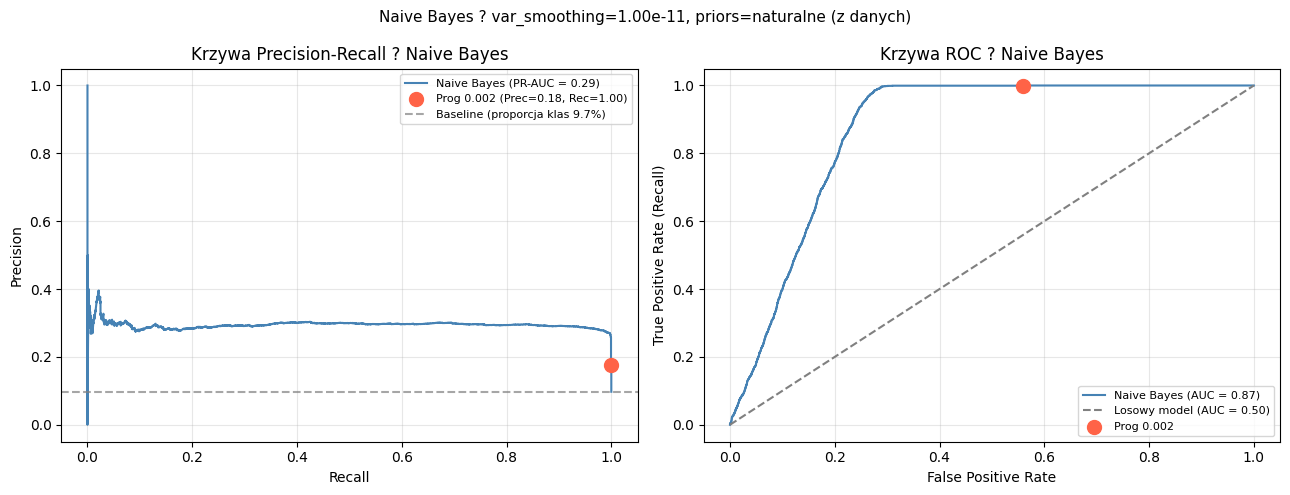

In [ ]:
prec_curve, rec_curve, thresholds_pr = precision_recall_curve(y_test, y_proba_test)
pr_auc = auc(rec_curve, prec_curve)

fpr, tpr, thresholds_roc = roc_curve(y_test, y_proba_test)
roc_auc_curve = auc(fpr, tpr)
idx_roc = np.argmin(np.abs(thresholds_roc - best_threshold))

# thresholds_pr ma o jeden element mniej niż precision/recall — punkt dla wybranego
# progu wyliczamy bezpośrednio z metryk testowych, żeby uniknąć przesunięcia indeksu
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(rec_curve, prec_curve, color='steelblue', label=f'Naive Bayes (PR-AUC = {pr_auc:.2f})')
axes[0].scatter([recall_test], [precision_test], color='tomato', zorder=5, s=100,
                label=f'Próg {best_threshold:.3f} (Prec={precision_test:.2f}, Rec={recall_test:.2f})')
axes[0].axhline(y=y_train.mean(), color='gray', linestyle='--', alpha=0.7,
                label=f'Baseline (proporcja klas {y_train.mean():.1%})')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Krzywa Precision-Recall - Naive Bayes')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].plot(fpr, tpr, color='steelblue', label=f'Naive Bayes (AUC = {roc_auc_curve:.2f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--', label='Losowy model (AUC = 0.50)')
axes[1].scatter([fpr[idx_roc]], [tpr[idx_roc]], color='tomato', zorder=5, s=100,
                label=f'Próg {best_threshold:.3f}')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate (Recall)')
axes[1].set_title('Krzywa ROC - Naive Bayes')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'Naive Bayes - var_smoothing={best_vs:.2e}, priors={best_priors_label}', fontsize=11)
plt.tight_layout()
plt.show()


## 3e. Wnioski — Naive Bayes

### Co wyszło

- **Recall = 1.0** na teście — cel spełniony, żaden zagrożony obiekt nie został przeoczony
- **ROC-AUC ~0.87** — całkiem przyzwoity ranking, biorąc pod uwagę, że założenia modelu są tu naruszone
- **Precision ~0.16–0.20** — na każdy prawdziwy alarm model generuje ~4–5 fałszywych. To wysoki koszt operacyjny, ale przy zerowej tolerancji na FN trudno inaczej

### Co robi `var_smoothing` i `priors`

- Największy wpływ `var_smoothing` widać w zakresie `[1e-9, 1e-4]`. Zbyt małe wartości mogą destabilizować numerycznie model przy bardzo skośnych cechach; zbyt duże (powyżej ~1e-2) zamazują różnice między klasami.
- `priors=[0.5, 0.5]` (lub zbliżone) mają sens przy nierównowadze 1:9 — przy priors naturalnych model traktuje klasę hazardous jako bardzo mało prawdopodobną i wymaga ekstremalnie niskiego progu (~0.007), co generuje jeszcze więcej FP.

### Gdzie GaussianNB ma problem w tym zadaniu

- **Założenie normalności jest naruszone** — cechy mają rozkłady silnie skośne z outliersami (prędkości, odległości w skali kosmicznej). Model estymuje dla nich gaussiana, co jest dużym uproszczeniem. Modele nieliniowe (drzewa, SVM z RBF) nie mają tego ograniczenia.
- **Cechy są wzajemnie zależne** — `est_diameter_min` i `absolute_magnitude` są fizycznie powiązane (większy obiekt = jaśniejszy w obserwacji). GaussianNB zakłada niezależność cech, co może prowadzić do ekstremalnych (źle skalibrowanych) prawdopodobieństw.
- **Porównanie z resztą zespołu** — spodziewamy się, że drzewa decyzyjne, SVM czy regresja logistyczna osiągną podobny Recall przy lepszej Precision, bo mogą modelować nieliniowe granice decyzyjne i nie mają powyższych ograniczeń strukturalnych.
